seeds: 207 candidates: 29504 hi: 0.21411007611544203 lo: 0.02404943030495892
mask sum: 22892 final_mask sum: 22871
centerline sum: 3032


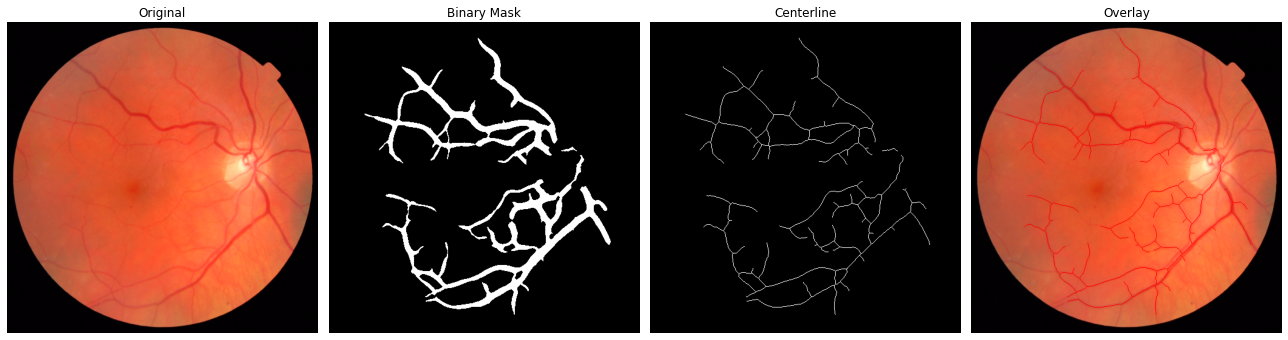

Results saved to: output_results\20051214_52695_0100_PP
Done.


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import morphology, measure, exposure
from skimage.filters import frangi, apply_hysteresis_threshold, gaussian
from skimage.morphology import disk, binary_erosion, remove_small_objects, reconstruction, binary_dilation
import os
import imageio
from skimage.filters import gaussian
from skimage.morphology import binary_closing, remove_small_objects
from skimage.segmentation import find_boundaries
from skimage.morphology import thin

def to_float01(x):
    """Standardizes image arrays to float32 in range [0, 1]."""
    x = x.astype(np.float32)
    if x.max() > 1.0: x /= 255.0
    return np.clip(x, 0, 1)

def compute_safety_fov(rgb):
    """
    Creates a mask that forcefully excludes the bright camera boundary ring
    and estimated the image radius.
    """
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)
    mask = mask.astype(bool)
    
    # Fill holes to get a solid circle
    mask = morphology.remove_small_holes(mask, area_threshold=1000)
    
    area = np.sum(mask)
    radius = np.sqrt(area / np.pi)
    
    # Erode significantly (12%) to kill the high-contrast boundary ring
    # which often tricks Frangi into making a circular vessel.
    fov_in = binary_erosion(mask, disk(int(radius * 0.06)))
    return fov_in, radius

def remove_exudates_inpainting(g, fov_in, radius):
    """
    Finds bright spots (exudates) and 'photoshops' them out using surrounding
    retinal texture. This prevents Frangi from seeing their edges.
    """
    # 1. Detect bright peaks (Exudates) using a local threshold
    # Exudates are much brighter than the average retina
    local_avg = gaussian(g, sigma=radius*0.05)
    bright_spots = (g > (local_avg + 0.1)) & fov_in
    
    # 2. Dilate the mask to cover the sharp edges of the lesions
    lesion_mask = binary_dilation(bright_spots, disk(int(radius * 0.02)))
    
    # 3. Inpaint the lesions using OpenCV
    g_u8 = (g * 255).astype(np.uint8)
    lesion_mask_u8 = (lesion_mask.astype(np.uint8) * 255)
    
    # TELEA inpainting fills the bright holes with the surrounding retinal color
    g_inpainted = cv2.inpaint(g_u8, lesion_mask_u8, inpaintRadius=5, flags=cv2.INPAINT_TELEA)
    
    return to_float01(g_inpainted)

def keep_only_disc_connected(mask, disc_mask, radius):
    """
    Keep only mask pixels that are connected to the optic disc boundary region.
    This removes disconnected blobs caused by exudates.
    """
    # create a thin ring around the optic disc as "seeds"
    ring_outer = binary_dilation(disc_mask, disk(int(max(6, radius * 0.06))))
    ring_inner = binary_dilation(disc_mask, disk(int(max(2, radius * 0.01))))
    ring = ring_outer & (~ring_inner)

    seeds = mask & ring
    if np.sum(seeds) == 0:
        # fallback: keep largest connected component
        lab = measure.label(mask)
        if lab.max() == 0:
            return mask
        regions = measure.regionprops(lab)
        largest = max(regions, key=lambda r: r.area)
        return (lab == largest.label)

    # morphological reconstruction: keep only parts connected to seeds
    rec = reconstruction(seeds.astype(np.uint8),
                         mask.astype(np.uint8),
                         method="dilation").astype(bool)
    return rec

def process_single_image(path):
    bgr = cv2.imread(path)
    if bgr is None: raise FileNotFoundError(f"Image not found: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    
    # 1. Get FOV and Radius
    fov_in, radius = compute_safety_fov(rgb)
    
    # 2. Extract Green
    g = to_float01(rgb[..., 1])

    # 3. Detect bright artifacts
    disc_mask = detect_optic_disc(g, fov_in, radius)
    exu_mask  = detect_exudates(g, fov_in, radius)
    bright_mask = exu_mask & fov_in
    g_clean = inpaint_mask(g, bright_mask, inpaint_radius=7)
    # 4. Better vessel enhancement: treat vessels as DARK ridges
    I = exposure.equalize_adapthist(g_clean, clip_limit=0.02)

    # remove slow illumination (background correction)
    bg = gaussian(I, sigma=radius * 0.10)
    I_hp = np.clip(bg - I, 0, 1)   # dark vessels become bright ridges
    I_hp = gaussian(I_hp, sigma=max(0.6, radius*0.002))
    ring = disc_ring(disc_mask, radius)
    I_hp[ring] = np.median(I_hp[fov_in & (~ring)])

    # 5. Frangi on ridge image
    V = frangi(
        I_hp,
        sigmas=np.arange(0.6, 6.0, 0.6),
        alpha=0.5,
        beta=0.5,
        gamma=15,
        black_ridges=False   # IMPORTANT
    )
    #sigmas=np.arange(1.0, 6.0, 1.0)
    
    # --- ROBUST NORMALIZATION INSIDE FOV ---
    V[~fov_in] = 0

    vals = V[fov_in]
    v1, v99 = np.percentile(vals, 1), np.percentile(vals, 99.5)

    V = np.clip((V - v1) / (v99 - v1 + 1e-8), 0, 1)
    V[~fov_in] = 0
    
    # 6. Final Segmentation with strict geometry filtering
    valid = fov_in & (~bright_mask)
    if np.sum(valid) < 1000:   # fallback if mask is too big
        valid = fov_in
    mask, lo, hi = disc_guided_hysteresis(V, fov_in, disc_mask, bright_mask, radius, hi_p=95, lo_p=82) 
    ring = disc_ring(disc_mask, radius)
    
    label_image = measure.label(mask)
    for region in measure.regionprops(label_image):
        coords = region.coords

        # fraction of this component that lies on exudates
        exu_dil = binary_dilation(exu_mask, disk(1))
        exu_frac = np.mean(exu_dil[coords[:, 0], coords[:, 1]])

        # remove components that are mostly on exudates (blobs/lesion edges)
        if exu_frac > 0.35 and region.area < 5000:
            mask[label_image == region.label] = False

    final_mask = remove_small_objects(mask, min_size=80)
    print("mask sum:", np.sum(mask), "final_mask sum:", np.sum(final_mask))
    centerline = thin(final_mask, max_iter=20)
    print("centerline sum:", np.sum(centerline))
    overlay = rgb.copy()
    overlay[centerline] = [255, 0, 0]    
    return rgb, g_clean, V, final_mask, centerline, overlay

def disc_guided_hysteresis(V, fov_in, disc_mask, bright_mask, radius, hi_p=97, lo_p=80):
    valid = fov_in & (~disc_mask)
    if np.sum(valid) < 1000:
        valid = fov_in

    hi = np.percentile(V[valid], hi_p)
    lo = np.percentile(V[valid], lo_p)

    # block lesions + their border so growth can't leak there
    no_go = binary_dilation(bright_mask, disk(int(max(2, radius*0.02))))  

    # candidates everywhere (low threshold), BUT not inside no_go
    # allow crossing the optic disc area (connectivity only)
    candidates = ((V > lo) | disc_mask) & fov_in & (~no_go)
    
    # seeds only near disc rim (high threshold), also not inside no_go
    ring_outer = binary_dilation(disc_mask, disk(int(max(10, radius * 0.06))))
    ring_inner = binary_dilation(disc_mask, disk(int(max(2,  radius * 0.01))))
    ring = ring_outer & (~ring_inner)
    seeds = (V > hi) & ring & fov_in & (~no_go)
    seeds = seeds & candidates   


    print("seeds:", np.sum(seeds), "candidates:", np.sum(candidates), "hi:", hi, "lo:", lo)

    # bridge tiny gaps, then RE-apply no_go so dilation doesn't jump into lesions
    mask = reconstruction(seeds.astype(np.uint8),
                          candidates.astype(np.uint8),
                          method="dilation").astype(bool)

    mask = binary_closing(mask, disk(2))

    return mask, lo, hi


def detect_optic_disc(g, fov_in, radius):
    """
    Detect optic disc as the largest bright blob inside FOV.
    Works best on green channel float [0,1].
    """
    # smooth to suppress vessels, keep large structures
    g_s = gaussian(g, sigma=max(2, radius * 0.03))

    # very bright threshold (adaptive-ish, per-image)
    t = np.percentile(g_s[fov_in], 99.2)  # you can tune 99.0-99.5
    disc = (g_s > t) & fov_in

    # close gaps -> one blob
    disc = binary_closing(disc, disk(int(max(3, radius * 0.03))))
    disc = remove_small_objects(disc, min_size=int(np.pi*(radius*0.06)**2))  # ~6% radius blob

    # keep only the largest component (optic disc is usually the biggest bright blob)
    lab = measure.label(disc)
    if lab.max() == 0:
        return np.zeros_like(disc, dtype=bool)

    regions = measure.regionprops(lab)
    largest = max(regions, key=lambda r: r.area)
    disc_mask = (lab == largest.label)

    # dilate a bit to cover the disc boundary (the part that kills you in Frangi)
    disc_mask = binary_dilation(disc_mask, disk(int(max(4, radius * 0.02))))
    return disc_mask


def detect_exudates(g, fov_in, radius):
    """
    Small bright lesions (exudates): local bright compared to local average.
    """
    local_avg = gaussian(g, sigma=max(2, radius * 0.05))
    bright = (g > (local_avg + 0.10)) & fov_in
    bright = binary_dilation(bright, disk(int(max(2, radius * 0.02))))
    bright = remove_small_objects(bright, min_size=int(max(20, radius * 0.002)))
    return bright

def disc_ring(disc_mask, radius):
    outer = binary_dilation(disc_mask, disk(int(max(6, radius * 0.03))))
    inner = binary_erosion(disc_mask,  disk(int(max(2, radius * 0.01))))
    return outer & (~inner)


def inpaint_mask(g, mask, inpaint_radius=5):
    g_u8 = (g * 255).astype(np.uint8)
    m_u8 = (mask.astype(np.uint8) * 255)
    out = cv2.inpaint(g_u8, m_u8, inpaintRadius=inpaint_radius, flags=cv2.INPAINT_TELEA)
    return to_float01(out)

def pick_percentile_for_fraction(V, valid, frac_target, p_init=95, p_min=60, p_max=99.9, iters=20):
    """
    Find percentile p such that mean(V > percentile(V,p)) ~= frac_target
    Uses a simple binary search over p.
    """
    lo, hi = p_min, p_max
    p = float(p_init)
    for _ in range(iters):
        thr = np.percentile(V[valid], p)
        frac = np.mean(V[valid] > thr)

        # if we keep too many pixels, threshold is too low => increase p
        if frac > frac_target:
            lo = p
            p = 0.5 * (p + hi)
        else:  # keep too few pixels => decrease p
            hi = p
            p = 0.5 * (p + lo)

    thr = np.percentile(V[valid], p)
    return thr, p

def save_results(img_path, rgb, mask, centerline, overlay):
    img_name = os.path.splitext(os.path.basename(img_path))[0]
    out_dir = os.path.join("output_results", img_name)
    os.makedirs(out_dir, exist_ok=True)

    imageio.imwrite(os.path.join(out_dir, "mask.png"), (mask.astype(np.uint8) * 255))
    imageio.imwrite(os.path.join(out_dir, "centerline.png"), (centerline.astype(np.uint8) * 255))
    imageio.imwrite(os.path.join(out_dir, "overlay.png"), overlay)

    plt.figure(figsize=(18, 5))
    plt.subplot(1,4,1); plt.imshow(rgb); plt.title("Original"); plt.axis("off")
    plt.subplot(1,4,2); plt.imshow(mask, cmap="gray"); plt.title("Binary Mask"); plt.axis("off")
    plt.subplot(1,4,3); plt.imshow(centerline, cmap="gray"); plt.title("Centerline"); plt.axis("off")
    plt.subplot(1,4,4); plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "summary.png"), dpi=200)
    plt.show()
    plt.close()

    print(f"Results saved to: {out_dir}")
    
if __name__ == "__main__":
    img_path = r"C:\Users\shake\Documents\computational biology course\final_project\retinal-graphs-compBio\data\messidor-2\20051214_52695_0100_PP.png"
    try:
        rgb_img, clean_g, prob_V, final_mask, centerline, overlay_img = process_single_image(img_path)

        save_results(
            img_path,
            rgb_img,
            final_mask,
            centerline,
            overlay_img
        )

        print("Done.")

    except Exception as e:
        print(f"Error: {e}")